In [3]:
import pandas as pd
import matplotlib.pyplot as plt
titanic=pd.read_csv("Titanic Dataset.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic.shape

(891, 12)

In [7]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [ ]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())

In [ ]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
titanic = titanic.drop("Cabin", axis=1)

In [ ]:
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

In [ ]:
titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Survival Distribution

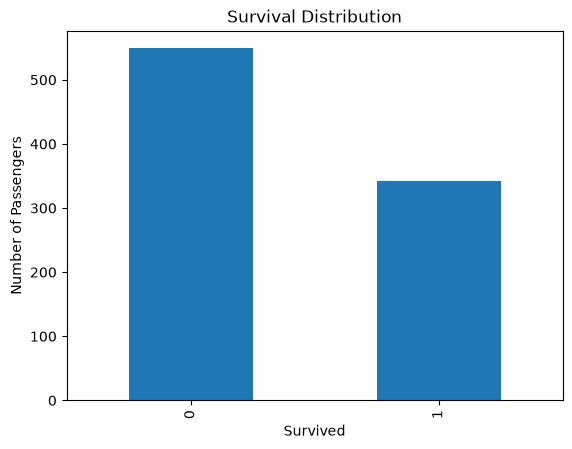

In [11]:

titanic["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

**Observation:**
- More passengers did not survive than survived.

## Distribution of Passenger Genders

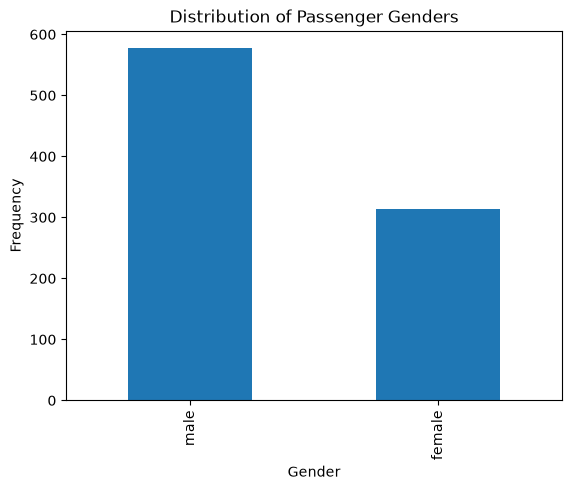

In [ ]:
titanic["Sex"].value_counts().plot(kind="bar")
plt.title("Distribution of Passenger Genders")
plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.show()

**Observation:**
- Male passengers were more than female passengers.

In [ ]:
titanic["Age"].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

## Distribution of passenger ages

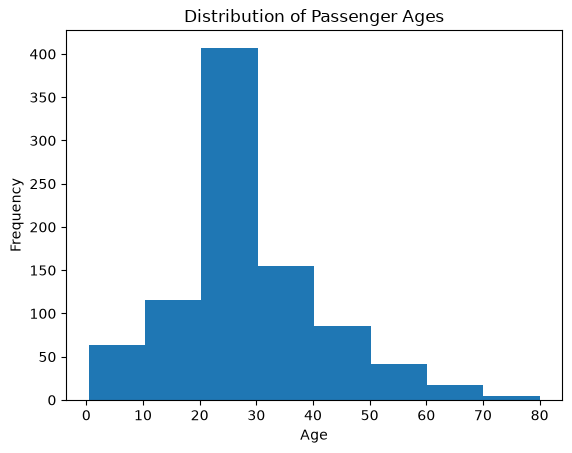

In [ ]:
plt.hist(titanic["Age"].dropna(), bins=8)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Observation:**
- Most passengers were between 20 – 40 years old.

In [ ]:
titanic["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

## Passenger Class Disrtibution

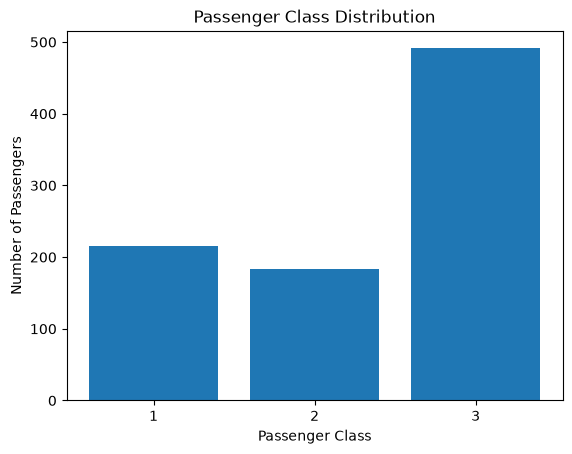

In [ ]:
class_count = titanic["Pclass"].value_counts().sort_index()

plt.bar(class_count.index, class_count.values)
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks([1, 2, 3])
plt.show()

**Observation:**
- Most passengers belonged to Third Class.

## Survival by Gender

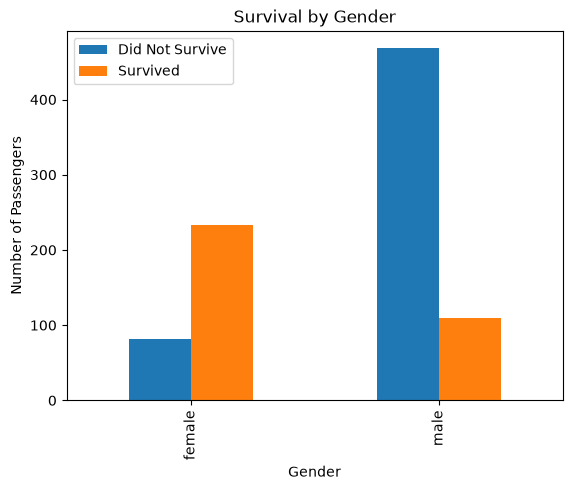

In [ ]:
pd.crosstab(titanic["Sex"], titanic["Survived"]).plot(kind="bar")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

**Observation:**
- Females had a much higher survival rate than males.

## Survival by Passenger class

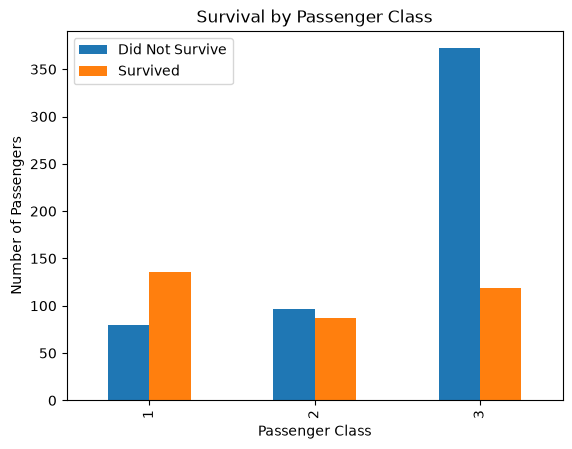

In [ ]:

pd.crosstab(titanic["Pclass"], titanic["Survived"]).plot(kind="bar")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

**Observation:**
- First Class passengers survived more often than Third Class passengers.

## Age Distribution by Survival Status

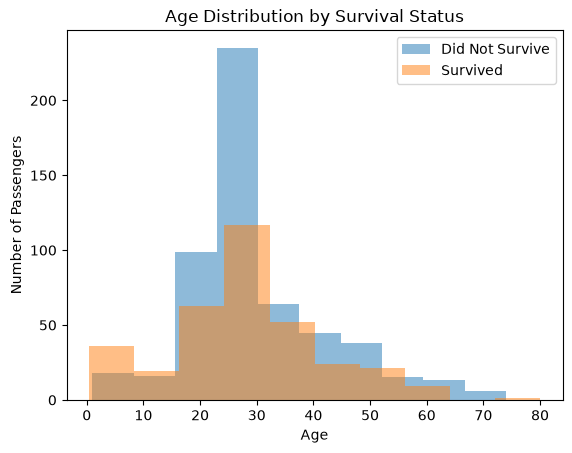

In [ ]:
import matplotlib.pyplot as plt

plt.hist(
    titanic[titanic["Survived"] == 0]["Age"].dropna(),
    bins=10,
    alpha=0.5,
    label="Did Not Survive"
)

plt.hist(
    titanic[titanic["Survived"] == 1]["Age"].dropna(),
    bins=10,
    alpha=0.5,
    label="Survived"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

**Observation:**
- Younger passengers (especially children) appear to have a relatively higher proportion of survivors compared to some adult age groups.

## Fare Distribution by Passenger Class

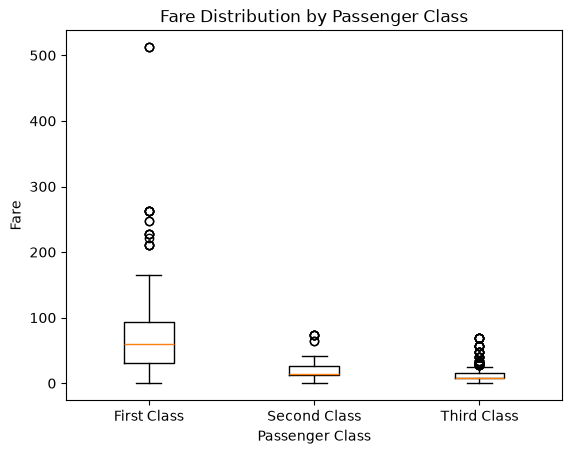

In [ ]:
plt.boxplot([
    titanic[titanic["Pclass"] == 1]["Fare"],
    titanic[titanic["Pclass"] == 2]["Fare"],
    titanic[titanic["Pclass"] == 3]["Fare"]
])

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.xticks([1, 2, 3], ["First Class", "Second Class", "Third Class"])

plt.show()

**Observations:**
- First Class passengers generally paid higher fares than Second and Third Class passengers.
- Third Class passengers paid the lowest fares overall.
- The fare distribution in First Class is more spread out, indicating greater variation in ticket prices.
- Several outliers are present, especially in First Class, showing that a few passengers paid exceptionally high fares.

## Correlation Heatmap

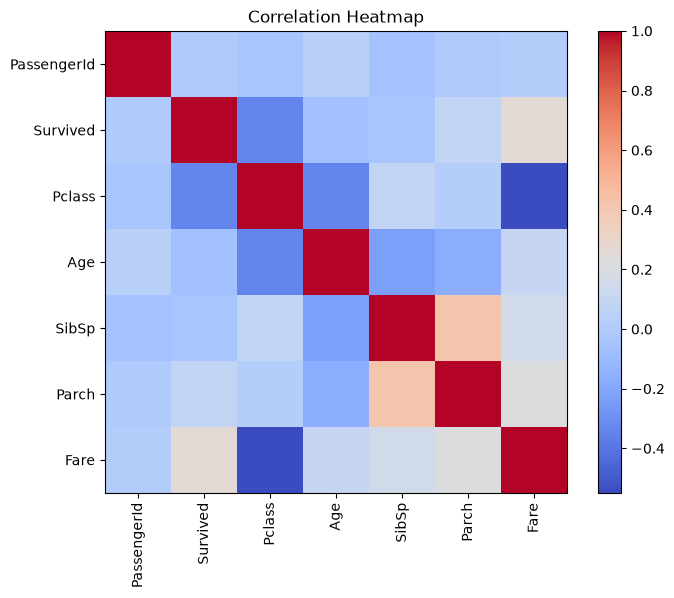

In [ ]:
numeric = titanic.select_dtypes(include="number")

corr = numeric.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()c

**Observation:**
- Pclass and Fare have a strong negative correlation, indicating that passengers in higher classes generally paid higher fares.
- Survived has a weak positive correlation with Fare, suggesting that passengers who paid higher fares had a slightly higher chance of survival.
- SibSp and Parch show a moderate positive correlation, indicating that passengers traveling with siblings/spouses were often also traveling with parents/children.
- Most other pairs of variables show weak correlations, suggesting no strong linear relationship between them.